# Simulations

In [1]:
import os
import sys

sys.path.insert(0, '/banach2/wes/locat-0.1')
sys.path.insert(0, '/banach2/wes/Locat-paper-repro-private/notebooks/figures/Simulations')

# If the old locat package was already imported in this kernel, clear it so imports below use locat-0.1.
for mod in list(sys.modules):
    if mod == 'locat' or mod.startswith('locat.'):
        del sys.modules[mod]


In [2]:
import os

In [3]:
!nvidia-smi

Tue Mar 17 12:04:16 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 525.125.06   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A6000    Off  | 00000000:01:00.0 Off |                  Off |
| 30%   58C    P2    98W / 300W |   2580MiB / 49140MiB |     13%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A6000    Off  | 00000000:24:00.0 Off |                  Off |
| 30%   

In [4]:
from numpy import random
import numpy as np

In [5]:
os.environ['CUDA_VISIBLE_DEVICES'] = '7'
SEED = 13
os.environ["PYTHONHASHSEED"] = str(SEED)

def reset_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    return seed

reset_seeds(SEED)


13

In [6]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.datasets import make_blobs

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
from sklearn.metrics import roc_curve

In [8]:
from locat.locat import LOCAT


In [9]:
adata_dir = "/banach2/wes/Locat/data/E145_dermal_erez_2026/"

In [10]:
adata = sc.read_h5ad(adata_dir+'dc_adata_proc.h5ad')

In [11]:
import numpy as np
import scanpy as sc
import scipy.sparse as sp


if "X_umap" in adata.obsm:
    coords_key = "X_umap"
elif "coords" in adata.obsm:
    coords_key = "coords"
else:
    raise KeyError("No 2D coords found in adata.obsm['X_umap'] or adata.obsm['coords'].")

coords = adata.obsm[coords_key].astype(np.float64)
n_cells = adata.n_obs

# ----------------------------
# Subsample genes: 999 random + Sox2 (total 1000)
# ----------------------------
target_gene = "Sox2"
if target_gene not in adata.var_names:
    raise ValueError(f"{target_gene} not found in adata.var_names")

rng = np.random.default_rng(0)

all_genes = adata.var_names.to_numpy()
other_genes = all_genes[all_genes != target_gene]

n_random = 999
if len(other_genes) < n_random:
    raise ValueError(f"Not enough genes to sample {n_random} excluding {target_gene} (only {len(other_genes)} available).")

rand_genes = rng.choice(other_genes, size=n_random, replace=False)
base_genes = np.concatenate([rand_genes, [target_gene]])

ad_base = adata[:, base_genes].copy()

# ----------------------------
# Helper: get Sox2 expression as a boolean vector (Sox2+)
# (works for sparse or dense .X)
# ----------------------------
sox2_vec = ad_base[:, target_gene].X
if sp.issparse(sox2_vec):
    sox2_vec = sox2_vec.toarray().ravel()
else:
    sox2_vec = np.asarray(sox2_vec).ravel()

sox2_pos = sox2_vec > 0
n_total = int(sox2_pos.sum())
if n_total == 0:
    raise ValueError("Sox2 has 0 expressing cells in this subset; cannot create bleeding variants.")


n_vars = 100                 # number of Sox2 copies
min_frac_keep = 0.03        # smallest fraction of Sox2+ cells to keep in the last variant
fractions_keep = np.linspace(1.0, min_frac_keep, n_vars)

sub_names = [f"{target_gene}_sub_{i:03d}" for i in range(n_vars)]

sox2_idx = np.flatnonzero(sox2_pos)  # indices of real Sox2+ cells

# optional: if you want nested subsampling (each variant is subset of previous),
# set nested=True. Otherwise each variant is an independent random sample at that size.
nested = True

sub_cols = []
if nested:
    # make one random ordering once; then take prefixes
    perm = rng.permutation(sox2_idx)
    for frac_keep in fractions_keep:
        n_keep = int(np.round(frac_keep * n_total))
        n_keep = max(0, min(n_keep, n_total))

        keep_idx = perm[:n_keep]
        col = sp.csr_matrix(
            (np.ones(len(keep_idx), dtype=np.float32),
             (keep_idx, np.zeros(len(keep_idx), dtype=int))),
            shape=(n_cells, 1)
        )
        sub_cols.append(col)
else:
    # independent samples at each size
    for frac_keep in fractions_keep:
        n_keep = int(np.round(frac_keep * n_total))
        n_keep = max(0, min(n_keep, n_total))

        keep_idx = rng.choice(sox2_idx, size=n_keep, replace=False) if n_keep > 0 else np.array([], dtype=int)
        col = sp.csr_matrix(
            (np.ones(len(keep_idx), dtype=np.float32),
             (keep_idx, np.zeros(len(keep_idx), dtype=int))),
            shape=(n_cells, 1)
        )
        sub_cols.append(col)

X_sub = sp.hstack(sub_cols, format="csr")


In [12]:
X0 = ad_base.X
if not sp.issparse(X0):
    X0 = sp.csr_matrix(X0)
else:
    X0 = X0.tocsr()

X_new = sp.hstack([X0, X_sub], format="csr")


In [13]:
import pandas as pd

n_base = ad_base.n_vars
n_sub = X_sub.shape[1]
assert X_new.shape[1] == n_base + n_sub

var_base = ad_base.var.copy()

# Build var_sub with same columns, but fill with dtype-appropriate defaults (no NaNs)
var_sub = pd.DataFrame(index=sub_names, columns=var_base.columns)

for c in var_base.columns:
    dt = var_base[c].dtype

    if pd.api.types.is_bool_dtype(dt):
        var_sub[c] = False
        var_sub[c] = var_sub[c].astype(bool)

    elif pd.api.types.is_integer_dtype(dt):
        var_sub[c] = 0
        var_sub[c] = var_sub[c].astype(dt)

    elif pd.api.types.is_float_dtype(dt):
        var_sub[c] = 0.0
        var_sub[c] = var_sub[c].astype(dt)

    elif pd.api.types.is_categorical_dtype(dt):
        # pick the first category if it exists, else empty string
        cats = var_base[c].cat.categories
        fill = cats[0] if len(cats) else ""
        var_sub[c] = pd.Categorical([fill] * len(sub_names), categories=cats)

    else:
        # safest for h5ad: real strings (not None)
        var_sub[c] = ""

var_new = pd.concat([var_base, var_sub], axis=0)

ad_sim = sc.AnnData(
    X=X_new,
    obs=ad_base.obs.copy(),
    var=var_new,
)

ad_sim.obsm[coords_key] = coords

if "X_pca" in adata.obsm:
    ad_sim.obsm["X_pca"] = adata.obsm["X_pca"].copy()

if "pca" in adata.uns:
    ad_sim.uns["pca"] = adata.uns["pca"].copy()

if "connectivities" in adata.obsp:
    ad_sim.obsp["connectivities"] = adata.obsp["connectivities"]
if "connectivities" not in ad_sim.obsp:
    sc.pp.neighbors(ad_sim, use_rep=coords_key, n_neighbors=30)
ad_sim.obsp["connectivities"] = adata.obsp["connectivities"]
ad_sim.uns["neighbors"] = adata.uns["neighbors"]

In [14]:
import scipy.sparse as sp
Xv = ad_sim[:, sub_names].X
totals = np.asarray((Xv > 0).sum(axis=0)).ravel() if sp.issparse(Xv) else (Xv > 0).sum(axis=0)
print("n_total real Sox2:", n_total)
print("sub totals first/last:", totals[0], totals[-1])
print("monotone decreasing?", np.all(np.diff(totals) <= 0))


n_total real Sox2: 187
sub totals first/last: 187 6
monotone decreasing? True


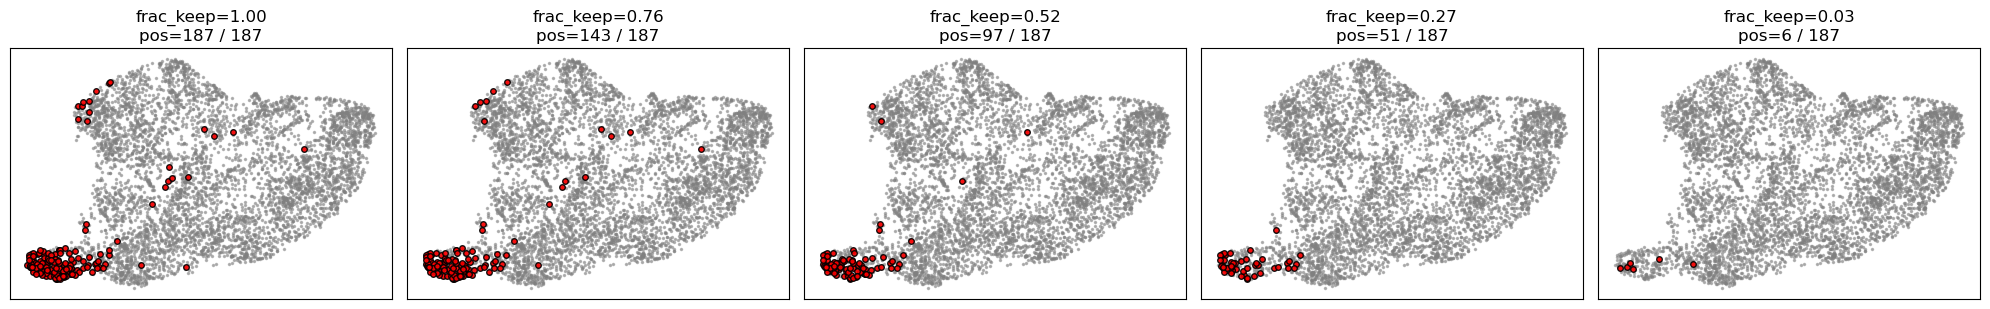

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

coords = ad_sim.obsm[coords_key]
n_tests = len(sub_names)

plt.figure(figsize=(20, 4))
i_plots = np.floor(np.linspace(0, n_tests - 1, 5)).astype(int)

for j, i in enumerate(i_plots):
    ax = plt.subplot(1, 5, j + 1)

    # background cells
    ax.plot(
        coords[:, 0], coords[:, 1],
        '.', markersize=3, color='gray', alpha=0.5
    )

    # KDE contour of overall cell density (optional)
   #sns.kdeplot(
   #    x=coords[:, 0], y=coords[:, 1],
   #    levels=7, color='k', linewidths=1,
   #    ax=ax
   #)

    # get positive cells for this subsampled Sox2 variant
    xcol = ad_sim[:, sub_names[i]].X
    if sp.issparse(xcol):
        pos = np.asarray(xcol.toarray()).ravel() > 0
    else:
        pos = np.asarray(xcol).ravel() > 0

    # overlay positives
    ax.plot(
        coords[pos, 0], coords[pos, 1],
        'o', markersize=4,
        markerfacecolor='r', markeredgecolor='k',
        alpha=0.9
    )

    n_pos = int(pos.sum())

    ax.set_title(
        f"frac_keep={fractions_keep[i]:.2f}\n"
        f"pos={n_pos} / {n_total}"
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


In [16]:
# view the two columns
#ad_sim.var = ad_sim.var.drop(columns=["is_partition1", "is_partition2"])


In [17]:
data_dir = "/banach2/wes/Locat-paper-repro-private/notebooks/figures/Simulations/"
ad_sim.write(data_dir+"support_files/sim_subs.h5ad")

In [18]:
adata = sc.read_h5ad(data_dir+"support_files/sim_subs.h5ad")
ad_sim = sc.read_h5ad(data_dir+"support_files/sim_subs.h5ad")
if "X_umap" in adata.obsm:
    coords_key = "X_umap"
elif "coords" in adata.obsm:
    coords_key = "coords"
else:
    raise KeyError("No 2D coords found in adata.obsm['X_umap'] or adata.obsm['coords'].")


In [19]:
%%time
# Assuming you already have LOCAT imported in your environment
# from locat import LOCAT  (or wherever your LOCAT class lives)

coords_sim = ad_sim.obsm[coords_key].astype(np.float64)

knn = ad_sim.obsp["connectivities"] if "connectivities" in ad_sim.obsp else None

reset_seeds(SEED)
m = LOCAT(
    ad_sim,
    coords_sim,
    20,
    show_progress=True,
    n_bootstrap_inits=100,
    knn=knn
)

m.background_pdf(force_refresh=True)

sres = {
    "full": m.gmm_scan(
        max_freq=1.0,
        rc_lambda_values=np.linspace(1.0, 2.0, 8),
        include_depletion_scan=True,
    ),
    "local": m.gmm_local_scan(zscore_thresh=-np.inf, max_freq=1.0),
    "llr": m.gmm_loglikelihoodtest(max_freq=1.0),
    "lpval": m.gmm_local_pvalue(),
}

# Convenience: locate the bleeding gene names
bleed_genes = np.array([g for g in ad_sim.var_names if g.startswith("Sox2_bleed_")], dtype=object)


2026-03-17 12:04:33.055 | INFO     | locat.locat:background_pdf:427 - fitting background PDF
2026-03-17 12:04:33.061 | INFO     | locat.locat:background_n_components_init:197 - Estimating number of GMM components
estimating BIC for 5572 cells:   0%|                                           | 0/9 [00:00<?, ?it/s]2026-03-17 12:04:33.071 | INFO     | locat.locat:min_dist:135 - recomputing min cell-cell distance
2026-03-17 12:04:33.071 | INFO     | locat.locat:cell_dist:127 - recomputing cell-cell distance
estimating BIC for 74 cells: 100%|███████████████████████████████████| 30/30 [00:41<00:00,  1.40s/it]
2026-03-17 12:06:04.017 | INFO     | locat.locat:background_pdf:439 - Using 15 components
fitting background: 100%|████████████████████████████████████████████| 10/10 [00:02<00:00,  3.58it/s]
null distribution parameters (perm. pseudo-genes): 100%|███████████████| 7/7 [01:17<00:00, 11.07s/it]
scanning genes: 100%|████████████████████████████████████████████| 1100/1100 [30:09<00:00,  1.6

CPU times: user 2h 35min 50s, sys: 8h 35min 36s, total: 11h 11min 26s
Wall time: 44min 56s


In [20]:
# LOCAT native p-values from locat-0.1 are used directly in this repro notebook.


In [21]:
# No permissive p_final recomputation is applied here.


In [22]:
if "X_pca" in adata.obsm:
    print(True)
    ad_sim.obsm["pca"] = adata.obsm["X_pca"].copy()

if "pca" in adata.uns:
    ad_sim.uns["pca"] = adata.uns["pca"].copy()

True


In [23]:
import cloudpickle as cp
def save_res(path):
    with open(f"{path}", "wb") as f:
        cp.dump(sres, f)

def load_res(path):
    with open(f"{path}", "rb") as f:
        loadedres = cp.load(f)
    return loadedres

In [24]:
#save sres
#save_res(path = "dermalc_subs_sres.pkl")

In [25]:
#load_res(path = "dermalc_subs_sres.pkl")

In [26]:
import simulations_compare_helpers as sim_helpers
from simulations_compare_helpers import (
    plotgenes,
    train_haystack_logpv_full,
    train_hotspot_full,
    train_clustering_logpadj,
    score_genes_with_graph_metrics,
    build_size_nulls,
    size_matched_pvalues,
)
srh = sim_helpers


In [27]:
%%time
# Assume: adata is log-normalized and adata.obsm['X_pca'] exists
scores = srh.score_genes_with_graph_metrics(
    ad_sim,
    n_neighbors=15,
    metric="euclidean",
    normalized_laplacian=True,  # L_sym (recommended)
    center=True,                # subtract per-gene means before scoring
    m_eigs=96,                  # try 64–256 (trade-off accuracy vs speed)
    use_connectivities=True,    # use scanpy’s kNN affinity graph
    layer=None                  # or your log layer name if you keep one
)
scores.head()


/home/wes/.conda/envs/mulde_jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CPU times: user 45min 56s, sys: 0 ns, total: 45min 56s
Wall time: 1min 21s


,rayleigh_smoothness,spectral_entropy
Timm8a1,0.910154,0.662465
Otud7a,0.983368,0.787884
Pde4dip,0.987886,0.827395
Ccdc178,0.962223,0.692892
Rab11a,0.981242,0.695267


In [28]:
%%time
# 0) pick layer to use (log-normalized, ideally nonnegative)
layer = None  # or e.g. "log1p"

# 1) ensure neighbors built from PCs, then Laplacian/eigs + nulls
# (assumes adata_filt.obsp['connectivities'] exists)
reset_seeds(SEED)
bank = srh.build_size_nulls(ad_sim, W_key='connectivities', layer=layer,
                        normalized_laplacian=True, m_eigs=96, P=4096, seed=42)

# 2) observed scores you already computed:
scores = ad_sim.var[['rayleigh_smoothness','spectral_entropy']]

# 3) size-matched p-values / percentiles
scores_sz = srh.size_matched_pvalues(scores, bank, two_sided=False)
scores_sz.head()

CPU times: user 1h 12min 20s, sys: 4min 30s, total: 1h 16min 50s
Wall time: 11min 39s


,rayleigh_smoothness,spectral_entropy,p_rayleigh_sizeNull,p_entropy_sizeNull,pct_rayleigh_sizeNull,pct_entropy_sizeNull
Timm8a1,0.910154,0.662465,1.000000,1.000000,1.000000,1.000000
Otud7a,0.983368,0.787884,0.092041,1.000000,0.092041,1.000000
Pde4dip,0.987886,0.827395,1.000000,1.000000,1.000000,1.000000
Ccdc178,0.962223,0.692892,0.001221,0.163086,0.001221,0.163086
Rab11a,0.981242,0.695267,1.000000,1.000000,1.000000,1.000000


In [29]:
scores_sz["HR_avg_sizeNull"] = scores_sz[["p_entropy_sizeNull", "pct_rayleigh_sizeNull"]].mean(axis=1)

In [30]:
%%time
SHres = dict()
res, trained_genes = train_haystack_logpv_full(
    ad_sim, 
    genesuse=ad_sim.var_names,
    emb="pca")
missing_genes = [i for i in list(ad_sim.var_names) if i not in list(trained_genes)]
missing_genes = np.random.default_rng(SEED).permutation(missing_genes)
trained_genes = np.concatenate([trained_genes, missing_genes])
ranks_res = [{i: list(trained_genes).index(i)} for i in list(ad_sim.var_names)]
SHres['ranks'] = ranks_res
SHres['out'] = res

> starting haystack ...
> entering array method ...
> scaling coordinates ...
> calculating feature stds ...
> calculating grid points ...
> calculating distance to cells ...
> calculating densities ...
> calculating Q dist ...
> calculating KLD for 1100 features ...


100%|██████████████████████████████████████████████████████████| 1100/1100 [00:00<00:00, 1168.02it/s]


> calculating feature's CV ...
> selecting genes to randomize ...
> calculating randomized KLD ...


100%|██████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  8.12it/s]


> calculating P values ...
> done.
CPU times: user 4min 41s, sys: 9min 50s, total: 14min 32s
Wall time: 55.4 s


In [31]:
pd.DataFrame(SHres["ranks"]).max(axis=0).sort_values()

Ube2c              0.0
Cdk1               1.0
Klf4               2.0
Col7a1             3.0
Sox2_sub_073       4.0
                 ...  
Oma1            1095.0
Cox15           1096.0
Aars2           1097.0
Fcer1g          1098.0
Ap4b1           1099.0
Length: 1100, dtype: float64

In [32]:
%%time
HSres = dict()
res, trained_genes = train_hotspot_full(
    ad_sim, 
    genesuse=ad_sim.var_names,
    emb="pca")
ranks_res = [{i: list(trained_genes).index(i)} for i in list(ad_sim.var_names)]
HSres['ranks'] = ranks_res
HSres["out"] = res

/home/wes/.conda/envs/mulde_jax/lib/python3.10/site-packages/hotspot/hotspot.py:98: UserWarning: Hotspot will work faster when counts are a csr sparse matrix.
  warnings.warn(
100%|████████████████████████████████████████████████████████████| 1100/1100 [00:16<00:00, 67.56it/s]


CPU times: user 2min 30s, sys: 6min 34s, total: 9min 5s
Wall time: 37.3 s


In [33]:
HSres["out"]

,C,Z,Pval,FDR
Gene,,,,
Ube2c,0.821947,266.390393,0.000000,0.000000
Cdk1,0.696363,225.747922,0.000000,0.000000
Klf4,0.672355,222.019292,0.000000,0.000000
Sox2,0.647292,207.893776,0.000000,0.000000
Sox2_sub_000,0.651901,207.463703,0.000000,0.000000
...,...,...,...,...
Oma1,-0.003882,-1.263147,0.896732,0.900005
Slc22a21,-0.004383,-1.369487,0.914576,0.917078
Rp2,-0.004685,-1.492624,0.932232,0.933592


In [34]:
import numpy as np
import scipy.sparse as sp
from giniclust3.gini import giniIndex, loessRegression, giniValueSelectionM

def custom_calGini(adata, selection="p_value", min_gini_value=0.6, p_value=0.0001):
    gene_labels = adata.var_names.tolist()
    cell_labels = adata.obs_names.tolist()

    print(f"Gene number is {len(gene_labels)}")
    print(f"Cell number is {len(cell_labels)}")

    X = adata.X
    if sp.issparse(X):
        X = X.toarray()  # cells x genes, dense

    # giniclust expects genes x cells
    gene_gini, gene_max = giniIndex(X.T)

    log_gene_max = np.log2(np.array(gene_max) + 0.1)
    adata.var["gini_score"] = np.array(gene_gini)

    if selection == "p_value":
        sig_gini_genes, _ = loessRegression(gene_gini, log_gene_max, gene_labels, min_gini_value, p_value)
        passed = set(sig_gini_genes.keys())
    elif selection == "gini_value":
        sig_gini_genes = giniValueSelectionM(gene_gini, gene_labels, min_gini_value)
        passed = set(sig_gini_genes.keys())
    else:
        raise ValueError("selection must be 'p_value' or 'gini_value'")

    adata.var["gini_pass"] = adata.var_names.isin(list(passed))
    print(f"Identified {int(adata.var['gini_pass'].sum())} high-Gini genes")
    return adata


In [35]:
%%time
ad_sim = custom_calGini(ad_sim, min_gini_value=0.6, p_value=0.0001, selection="gini_value")

Gene number is 1100
Cell number is 5572
Identified 931 high-Gini genes
CPU times: user 291 ms, sys: 0 ns, total: 291 ms
Wall time: 291 ms


In [36]:
data_dir = "/banach2/wes/Locat-paper-repro-private/notebooks/figures/Simulations/"

In [37]:
gspa_data = np.load(data_dir + "support_files/gspa_output_subs_comp_repro.npz", allow_pickle=True)
gspa_var_names = gspa_data["var_names"]
gspa_gene_localization = gspa_data["gene_localization"]

In [38]:
ad_sim

AnnData object with n_obs × n_vars = 5572 × 1100
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'ngene_lth', 'ngene_hth', 'mt_hth', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'log_nCount_RNA', 'log_nFeature_RNA', 'RNA_snn_res.0.3', 'seurat_clusters', 'cluster', 'tmp.ident', 'RNA_snn_res.0.5', 'celltype'
    var: 'is_partition1', 'is_partition2', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'rayleigh_smoothness', 'spectral_entropy', 'gini_score', 'gini_pass'
    uns: 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap', 'pca'
    obsp: 'connectivities', 'distances'

In [39]:
adata

AnnData object with n_obs × n_vars = 5572 × 1100
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'ngene_lth', 'ngene_hth', 'mt_hth', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'log_nCount_RNA', 'log_nFeature_RNA', 'RNA_snn_res.0.3', 'seurat_clusters', 'cluster', 'tmp.ident', 'RNA_snn_res.0.5', 'celltype'
    var: 'is_partition1', 'is_partition2', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities'

In [40]:
ad_sim.var["gspa"] = gspa_gene_localization

In [41]:
lmd_res = np.load(data_dir+"support_files/LMD_output_subs_comp_repro.npz",  allow_pickle=True)

In [42]:
var_names = lmd_res["var_names"]
gene_localization = lmd_res["gene_localization"]

In [43]:
lmd_res = pd.DataFrame({
    "var_names": var_names,
    "LMD_score": gene_localization}).set_index("var_names")

In [44]:
ad_sim.obsp["connectivities"] = adata.obsp["connectivities"]
ad_sim.uns["neighbors"] = adata.uns["neighbors"]

In [45]:
%%time
STres = dict()
clust = train_clustering_logpadj(ad_sim, genesuse=ad_sim.var_names)
ranked_genes = clust.index.to_list()
rank_map = {g: i for i, g in enumerate(ranked_genes)}

# If some genes didn't appear (shouldn’t, but safe), give them worst rank
worst = len(ranked_genes)
STres["truth"] = [{g: rank_map.get(g, worst)} for g in ad_sim.var_names]

CPU times: user 34.4 s, sys: 0 ns, total: 34.4 s
Wall time: 5.64 s


In [46]:
#clust
clust["pvals_adj"]

gene
Smc4       0.000000e+00
Cdk1       0.000000e+00
Meg3       0.000000e+00
Ube2c      0.000000e+00
Ska1      7.516180e-266
              ...      
Fcer1g     9.434473e-01
Usp35      9.445505e-01
Egf        9.576647e-01
Tor3a      9.581033e-01
Acot11     9.703868e-01
Name: pvals_adj, Length: 1100, dtype: float64

In [47]:
#spectralRH
scores_sz["HR_avg_sizeNull"]#.value_counts()

Timm8a1         1.000000
Otud7a          0.546021
Pde4dip         1.000000
Ccdc178         0.082153
Rab11a          1.000000
                  ...   
Sox2_sub_095    0.001587
Sox2_sub_096    0.000854
Sox2_sub_097    0.000732
Sox2_sub_098    0.004883
Sox2_sub_099    0.003174
Name: HR_avg_sizeNull, Length: 1100, dtype: float64

In [48]:
#HAYSTACK
SHres['out']

,gene,KLD,CV,pval,pval_adj,logpval,logpval_adj
0,Timm8a1,0.000047,1.121351,1.638203e-10,1.802024e-07,-9.785632,-6.744240
1,Otud7a,0.000301,7.699724,1.101031e-02,1.000000e+00,-1.958200,0.000000
2,Pde4dip,0.000035,2.430498,6.081162e-02,1.000000e+00,-1.216013,0.000000
3,Ccdc178,0.001060,9.449036,1.786124e-06,1.964736e-03,-5.748088,-2.706696
4,Rab11a,0.000015,1.000435,2.925672e-04,3.218239e-01,-3.533774,-0.492382
...,...,...,...,...,...,...,...
1095,Sox2_sub_095,0.018419,20.678863,3.192498e-22,3.511748e-19,-21.495869,-18.454477
1096,Sox2_sub_096,0.018905,22.484337,4.315460e-21,4.747006e-18,-20.364973,-17.323580
1097,Sox2_sub_097,0.015608,24.861841,5.160174e-17,5.676192e-14,-16.287336,-13.245943
1098,Sox2_sub_098,0.014316,28.195745,1.103730e-13,1.214103e-10,-12.957137,-9.915744


In [49]:
#HOTSPOT
HSres["out"]

,C,Z,Pval,FDR
Gene,,,,
Ube2c,0.821947,266.390393,0.000000,0.000000
Cdk1,0.696363,225.747922,0.000000,0.000000
Klf4,0.672355,222.019292,0.000000,0.000000
Sox2,0.647292,207.893776,0.000000,0.000000
Sox2_sub_000,0.651901,207.463703,0.000000,0.000000
...,...,...,...,...
Oma1,-0.003882,-1.263147,0.896732,0.900005
Slc22a21,-0.004383,-1.369487,0.914576,0.917078
Rp2,-0.004685,-1.492624,0.932232,0.933592


In [50]:
#GINI
ad_sim.var["gini_score"].value_counts()

gini_score
0.598392    1
0.889583    1
0.900801    1
0.899956    1
0.990869    1
           ..
0.964963    1
0.853841    1
0.870060    1
0.691161    1
0.998831    1
Name: count, Length: 1100, dtype: int64

In [51]:
#LMD
lmd_res

,LMD_score
var_names,
Timm8a1,9.292311
Otud7a,8.624225
Pde4dip,9.418986
Ccdc178,8.268684
Rab11a,9.623533
...,...
Sox2_sub_095,6.317907
Sox2_sub_096,6.406302
Sox2_sub_097,6.551538


In [52]:
#GSPA
ad_sim.var["gspa"].sort_values()

Rplp2        0.355365
Rplp1        0.366311
Rps29        0.429802
Rpl32        0.436951
Rpl38        0.468971
              ...    
Kif4         8.537531
Cdk1         9.285428
Hist1h1a     9.445808
Klf4         9.778049
Ube2c       10.739279
Name: gspa, Length: 1100, dtype: float64

In [53]:
#sc.pl.embedding(ad_sim,basis="coords",color=["Gene_64","Gene_94","Gene_31","Gene_190","Gene_193","Gene_199"], s=50, cmap="Reds")

In [54]:
from scipy.stats import combine_pvalues
p1 = scores_sz["p_entropy_sizeNull"].to_numpy()
p2 = scores_sz["p_rayleigh_sizeNull"].to_numpy()
p_comb = np.array([combine_pvalues([a,b], method="fisher")[1] for a,b in zip(p1,p2)])
scores_sz["p_srh_sizeNull_fisher"] = p_comb
srh_p = scores_sz["p_srh_sizeNull_fisher"]

In [55]:
locat_df = pd.DataFrame({gene: res._asdict() for gene, res in sres["full"].items()}).T
locat_df.index.name = "gene"
locat_df

,gene_name,bic,zscore,sens_score,depletion_pval,concentration_pval,h_size,h_sens,pval,K_components,sample_size,depletion_scan
gene,,,,,,,,,,,,
Timm8a1,Timm8a1,-0.144724,9.444095,0.417147,0.066737,0.0,0.00036,0.582853,0.069959,3,2776.0,"{'p_value': 0.06673687623172946, 'raw_min_p': ..."
Otud7a,Otud7a,0.220582,4.744239,0.633663,0.000321,0.000001,0.009756,0.366337,0.044429,2,101.0,"{'p_value': 0.0003213795118273683, 'raw_min_p'..."
Pde4dip,Pde4dip,-0.062883,-1.137023,0.359462,0.22186,0.872236,0.001118,0.640538,0.693066,3,893.0,"{'p_value': 0.2218595615463987, 'raw_min_p': 0..."
Ccdc178,Ccdc178,0.200396,10.013301,0.855072,0.0,0.0,0.014184,0.144928,0.018088,2,69.0,"{'p_value': 2.3857248751145974e-07, 'raw_min_p..."
Rab11a,Rab11a,-0.143134,5.595604,0.36,0.197175,0.0,0.00032,0.64,0.076815,3,3125.0,"{'p_value': 0.19717511224343898, 'raw_min_p': ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
Sox2_sub_095,Sox2_sub_095,-3.018578,8.373898,1.0,0.0,0.0,0.068937,0.0,0.003447,1,13.0,"{'p_value': 2.3104834295090143e-08, 'raw_min_p..."
Sox2_sub_096,Sox2_sub_096,-3.445959,7.406516,1.0,0.0,0.0,0.079956,0.0,0.003998,1,11.0,"{'p_value': 1.6975182525131788e-07, 'raw_min_p..."
Sox2_sub_097,Sox2_sub_097,-5.240632,6.530807,1.0,0.000008,0.0,0.095163,0.0,0.004758,1,9.0,"{'p_value': 7.835529776772648e-06, 'raw_min_p'..."


In [56]:
#Locat
locat_p = locat_df["pval"].astype(float)
locat_conc_p = locat_df["concentration_pval"].astype(float)
locat_llr_p = pd.DataFrame(sres["llr"]).T["llratio_pvalue"].astype(float)
locat_perm_p = pd.DataFrame(sres["lpval"]).T["zscore_pvalue"].astype(float)


In [57]:
sub_indices = [f"Sox2_sub_{i:03d}" for i in range(len(fractions_keep))]
truth_keep = pd.Series(fractions_keep, index=sub_indices, name="frac_keep")
x = truth_keep.reindex(sub_indices).to_numpy()


In [58]:
# clustering: DataFrame indexed by gene with pvals_adj
clust_p = clust["pvals_adj"].astype(float)

# hotspot: DataFrame indexed by gene with FDR
hotspot_p = HSres["out"]["FDR"].astype(float)

# haystack: DataFrame with gene + pval_adj
haystack_p = SHres["out"].set_index("gene")["pval_adj"].astype(float)

# spectralRH size-null score is already "p-like" (smaller better)
srh_p = scores_sz["HR_avg_sizeNull"].astype(float)

# GSPA: score -> rank-based p (monotone, not calibrated)
gspa = ad_sim.var["gspa"].astype(float)
gspa_rankp = (gspa.rank(ascending=False, method="average") / (len(gspa) + 1)).astype(float)

lmd = lmd_res["LMD_score"].astype(float)
lmd_rankp = (lmd.rank(ascending=True, method="average") / (len(lmd) + 1)).astype(float)



In [59]:
gspa

Timm8a1         3.383687
Otud7a          2.538722
Pde4dip         2.763320
Ccdc178         2.764471
Rab11a          2.279503
                  ...   
Sox2_sub_095    3.831578
Sox2_sub_096    3.787462
Sox2_sub_097    3.682085
Sox2_sub_098    3.464083
Sox2_sub_099    3.322885
Name: gspa, Length: 1100, dtype: float64

In [60]:
lmd

var_names
Timm8a1         9.292311
Otud7a          8.624225
Pde4dip         9.418986
Ccdc178         8.268684
Rab11a          9.623533
                  ...   
Sox2_sub_095    6.317907
Sox2_sub_096    6.406302
Sox2_sub_097    6.551538
Sox2_sub_098    6.692028
Sox2_sub_099    6.541014
Name: LMD_score, Length: 1100, dtype: float64

In [61]:
srh_p

Timm8a1         1.000000
Otud7a          0.546021
Pde4dip         1.000000
Ccdc178         0.082153
Rab11a          1.000000
                  ...   
Sox2_sub_095    0.001587
Sox2_sub_096    0.000854
Sox2_sub_097    0.000732
Sox2_sub_098    0.004883
Sox2_sub_099    0.003174
Name: HR_avg_sizeNull, Length: 1100, dtype: float64

In [62]:
haystack_p

gene
Timm8a1         1.802024e-07
Otud7a          1.000000e+00
Pde4dip         1.000000e+00
Ccdc178         1.964736e-03
Rab11a          3.218239e-01
                    ...     
Sox2_sub_095    3.511748e-19
Sox2_sub_096    4.747006e-18
Sox2_sub_097    5.676192e-14
Sox2_sub_098    1.214103e-10
Sox2_sub_099    5.229190e-11
Name: pval_adj, Length: 1100, dtype: float64

In [63]:
hotspot_p

Gene
Ube2c            0.000000
Cdk1             0.000000
Klf4             0.000000
Sox2             0.000000
Sox2_sub_000     0.000000
                   ...   
Oma1             0.900005
Slc22a21         0.917078
Rp2              0.933592
Fcer1g           0.933592
3110001I22Rik    0.953424
Name: FDR, Length: 1100, dtype: float64

In [64]:
clust_p

gene
Smc4       0.000000e+00
Cdk1       0.000000e+00
Meg3       0.000000e+00
Ube2c      0.000000e+00
Ska1      7.516180e-266
              ...      
Fcer1g     9.434473e-01
Usp35      9.445505e-01
Egf        9.576647e-01
Tor3a      9.581033e-01
Acot11     9.703868e-01
Name: pvals_adj, Length: 1100, dtype: float64

In [67]:
from pathlib import Path
FIG_DIR = Path("DermalC_sim_repro_svgs")
FIG_DIR.mkdir(exist_ok=True)
def save_svg(fig, stem):
    import matplotlib.pyplot as plt

    if fig is None:
        fig = plt.gcf()
    path = FIG_DIR / f"{stem}.svg"
    fig.savefig(path, format="svg", bbox_inches="tight")
    print(f"Saved {path}")
    return fig

Saved DermalC_sim_repro_svgs/sox2_subsampling_sensitivity_methods.svg


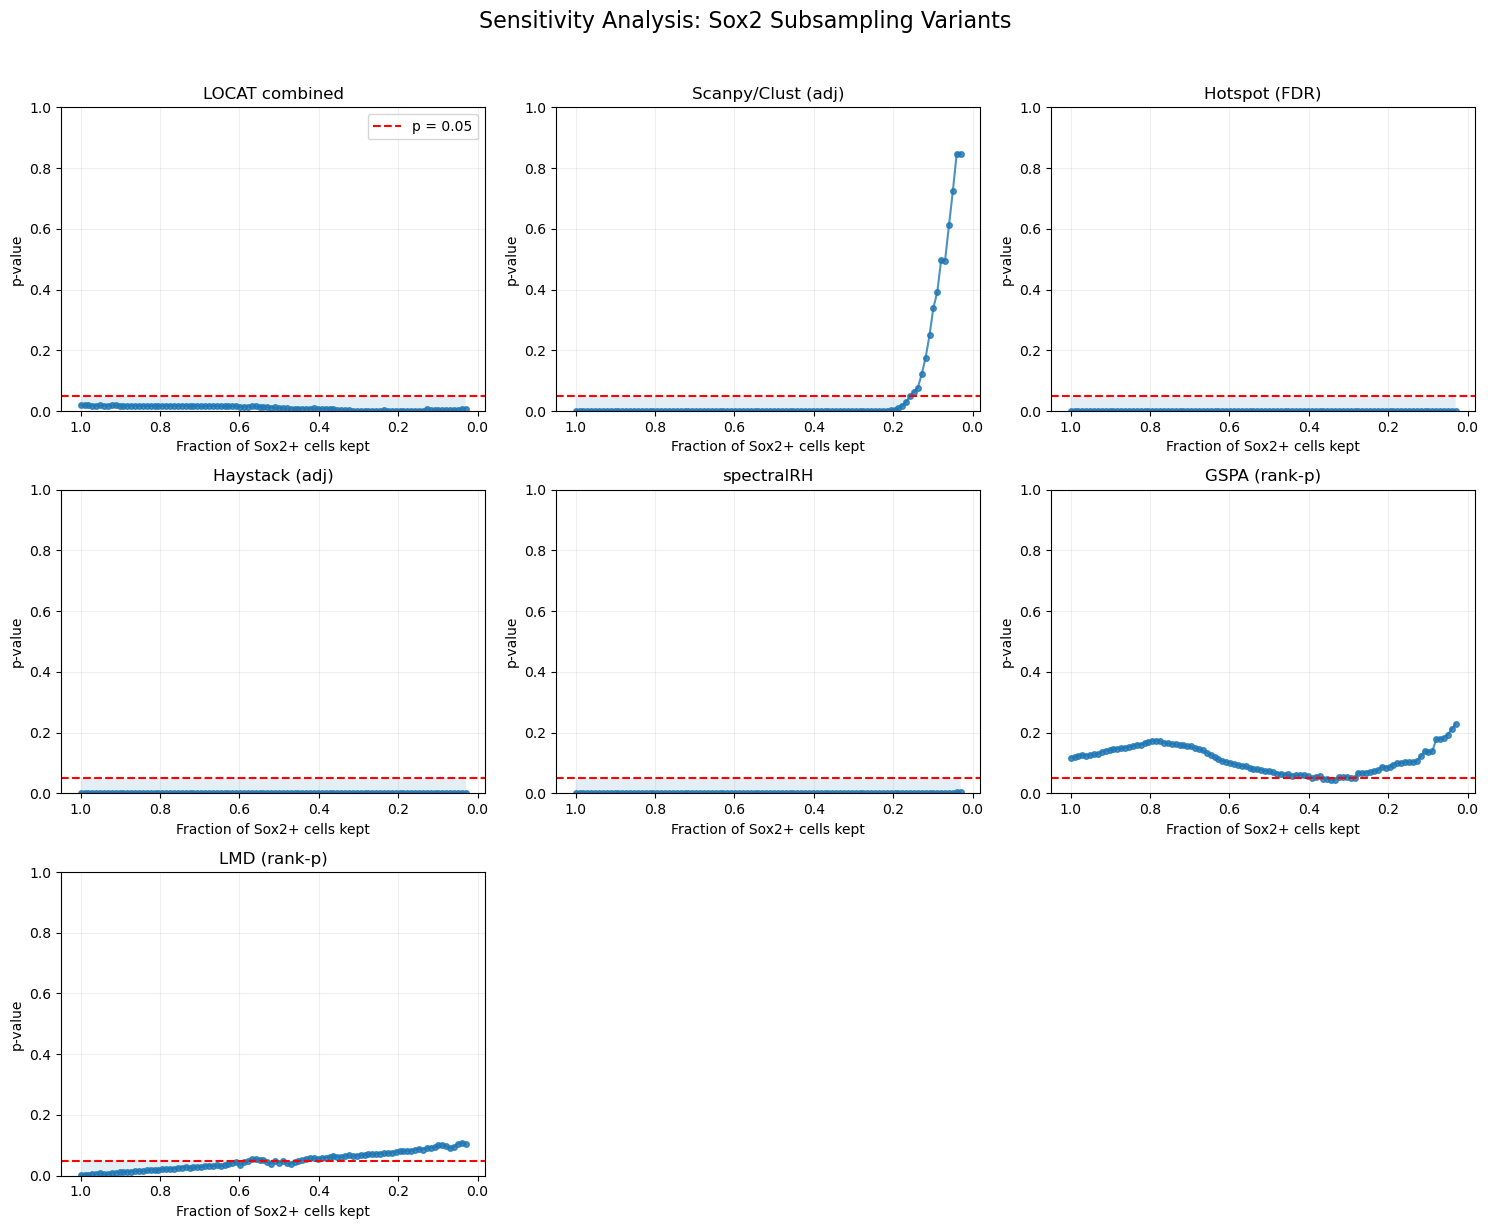

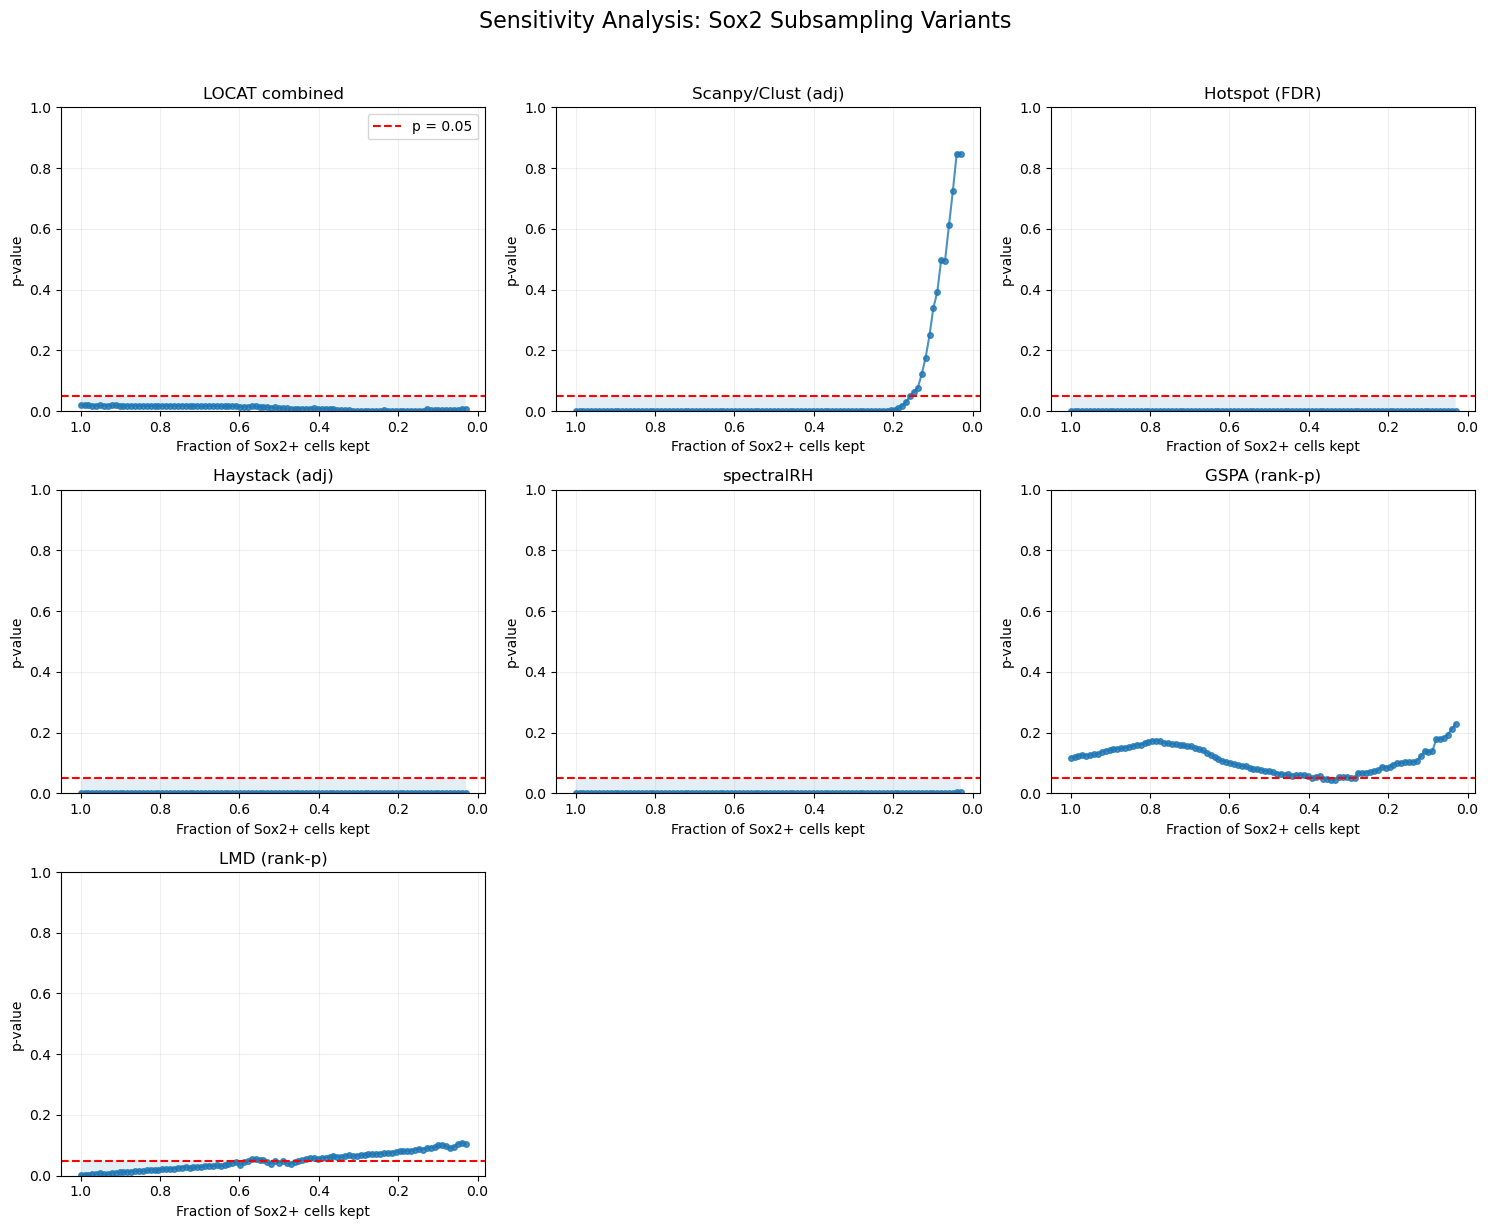

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sub_indices = [f"Sox2_sub_{i:03d}" for i in range(100)]
x_vals = fractions_keep

sig_p = 0.05
methods = {
    "LOCAT combined": locat_p,
    "Scanpy/Clust (adj)": clust_p,
    "Hotspot (FDR)": hotspot_p,
    "Haystack (adj)": haystack_p,
    "spectralRH": srh_p,
    "GSPA (rank-p)": gspa_rankp,
    "LMD (rank-p)": lmd_rankp,
}

n = len(methods)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig = plt.figure(figsize=(5 * ncols, 4 * nrows))

for i, (name, pv) in enumerate(methods.items(), 1):
    pv_sub = pd.Series(pv).reindex(sub_indices).astype(float).to_numpy()

    ax = plt.subplot(nrows, ncols, i)
    ax.plot(x_vals, pv_sub, 'o-', markersize=4, alpha=0.8)
    ax.axhline(sig_p, color="red", linestyle="--", linewidth=1.5, label="p = 0.05")
    ax.fill_between(
        x_vals, pv_sub, sig_p,
        where=(pv_sub <= sig_p),
        alpha=0.12
    )

    ax.set_title(name)
    ax.set_xlabel("Fraction of Sox2+ cells kept")
    ax.set_ylabel("p-value")
    ax.invert_xaxis()
    ax.grid(True, alpha=0.2)
    ax.set_ylim(0.0, 1.0)

    if i == 1:
        ax.legend(loc="upper right")

fig.suptitle("Sensitivity Analysis: Sox2 Subsampling Variants", fontsize=16, y=1.02)
fig.tight_layout()

save_svg(fig, "sox2_subsampling_sensitivity_methods")
display(fig)


In [126]:
sig_y = -np.log10(0.05)  # ≈ 1.3010
half = 16.0
ylim = (sig_y - half, sig_y + half)

In [127]:
locat_conc_p

Gene_0      1.000000e-15
Gene_1      1.000000e-15
Gene_2      1.000000e-15
Gene_3      1.000000e-15
Gene_4      1.000000e-15
                ...     
Gene_195    3.152992e-05
Gene_196    1.000000e-15
Gene_197    8.659454e-02
Gene_198    4.125725e-11
Gene_199    1.000000e-15
Name: concentration_pval, Length: 200, dtype: float64